# This notebook is used to prototype filters for extending the framework to multiple partitions, start with 1d since they are (for now) isotropic

In [1]:
import filters
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [10, 5]
EPSILON = 1e-5

## Original filters used for multistep framework

In [2]:
ells = [3, 10, 35, 70]
deltas = [0, 0, 0, 0]
sigma2s = [1, 1, 1, 1, 1]
names = ["<3", "3-10", "10-35", "35-70", ">70"]
colours = ["teal", "crimson", "forestgreen", "violet", "blue"]
plot_mask = [True, True, False, False, False]

### Compute and plot transfer functions

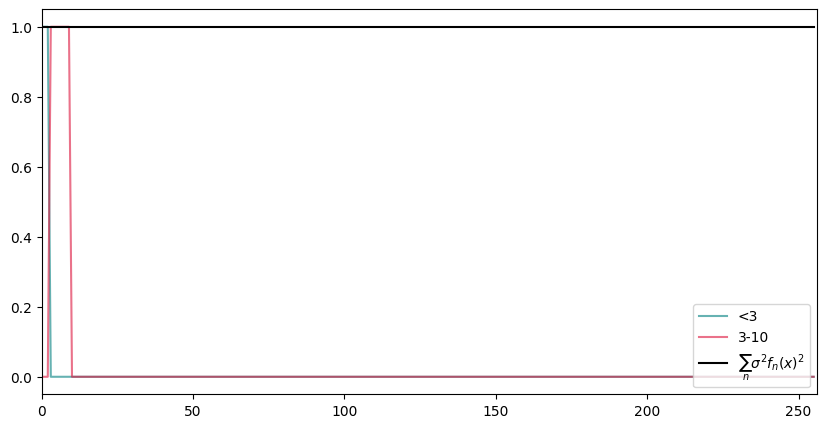

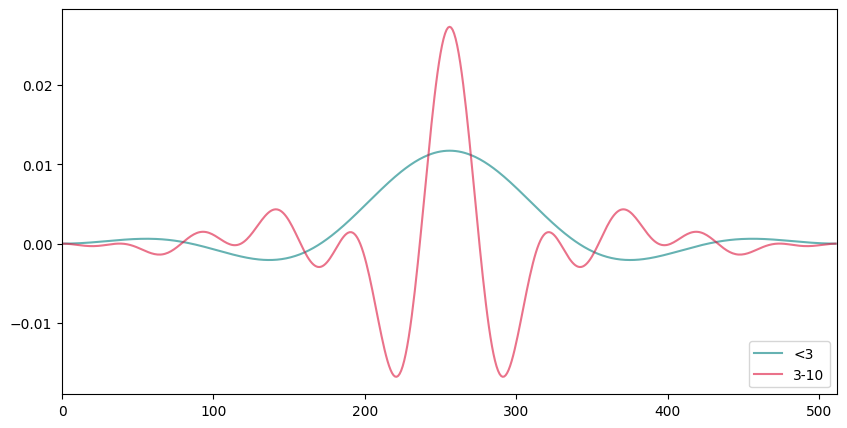

In [3]:
filter_vals, xvals, filter_sum = filters.create_filters_mstep(256, deltas, ells, sigma2s)
filter_sum = np.array(filter_sum)
filter_vals_nparr = [np.array(filt) for filt in filter_vals]

filters.plot_filters(names, filter_vals_nparr, filter_sum, colours, plot_mask)

filters_spatial = filters.compute_spatial_filters(filter_vals_nparr)
filters.plot_filters(names, filters_spatial, None, colours, plot_mask)

## Windowed Sinc

At a cursory glance, this filter, with the kaiser window, seems to behave very similarly to what is used in the multi-step method, given a somewhat large window and $\beta$.

### Lowpass prototype visualization

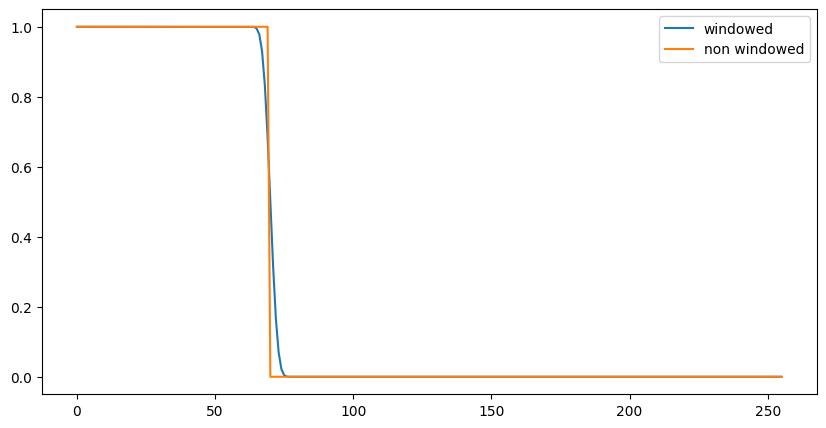

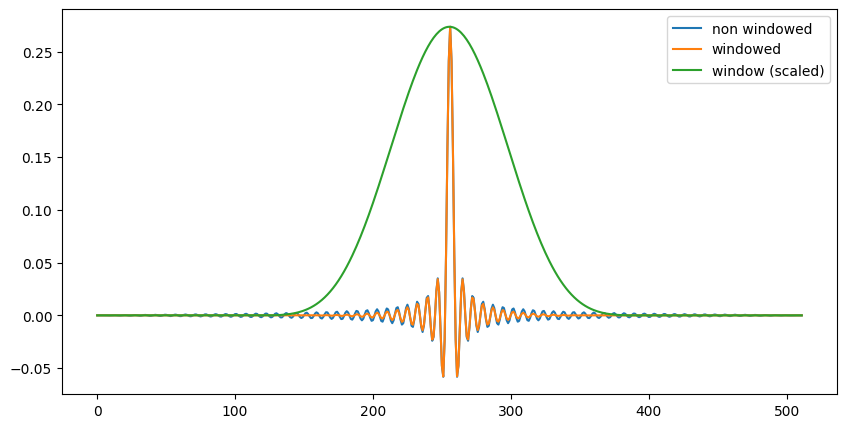

In [4]:
tf_nw, spatial_nw, tf_w, spatial_w, window = filters.windowed_sinc_lp(70, 512, 256, "kaiser", kaiser_beta=10)
plt.plot(tf_w.real, label="windowed")
plt.plot(tf_nw.real, label="non windowed")
plt.legend(loc="upper right")
plt.show()
plt.plot(spatial_nw, label="non windowed")
plt.plot(spatial_w, label="windowed")
window = window * np.max(spatial_nw)
plt.plot(window, label="window (scaled)")
plt.legend(loc="upper right")
plt.show()

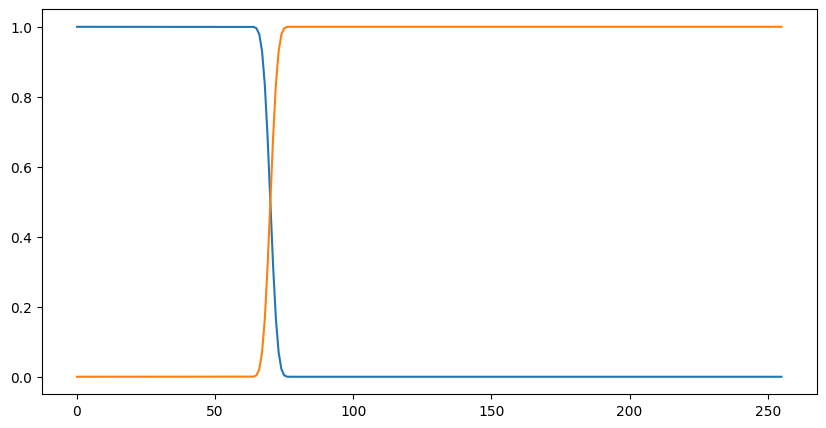

In [5]:
shifted = filters.lp_to_hp(spatial_w)
plt.plot(tf_w.real)
plt.plot(shifted[0].real)
plt.show()

### Filter bank visualization

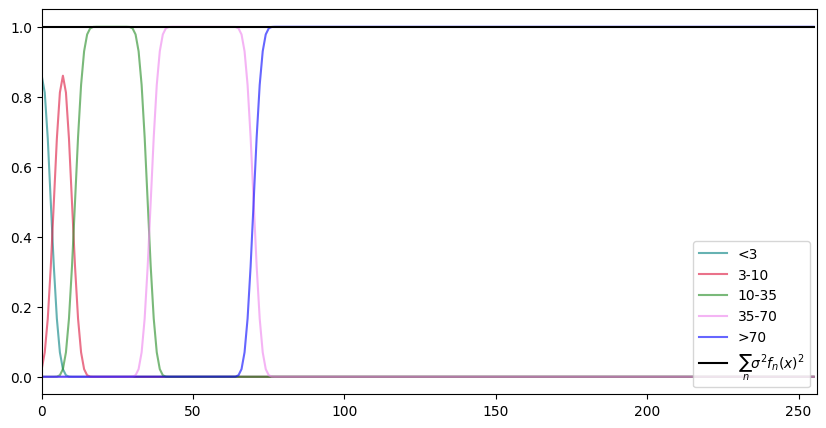

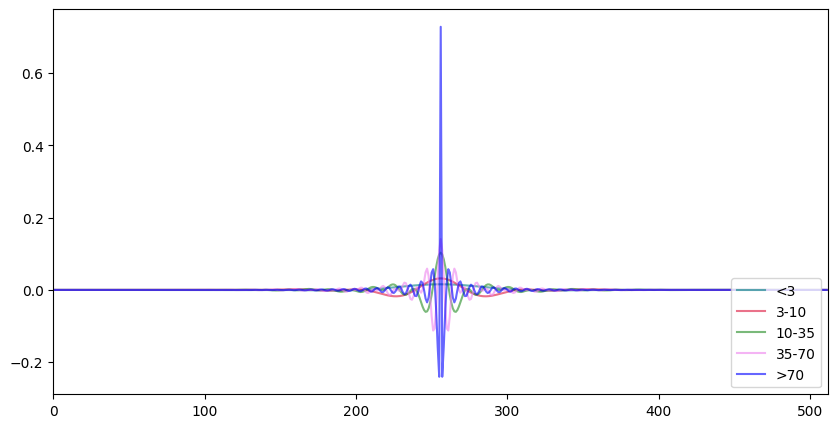

In [12]:
sigma2s = [1, 1, 1, 1, 1]
names = ["<3", "3-10", "10-35", "35-70", ">70"]
colours = ["teal", "crimson", "forestgreen", "violet", "blue"]
plot_mask = [True, True, True, True, True, True]

windowed_sinc_filters = []

_, _, _, spatial_w, _ = filters.windowed_sinc_lp(3, 512, 256, "kaiser", kaiser_beta=10)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, 0)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((10 - 3)//2, 512, 256, "kaiser", kaiser_beta=10)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (10 + 3)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((35-10)//2, 512, 256, "kaiser", kaiser_beta=10)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (35 + 10)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp((70-35)//2, 512, 256, "kaiser", kaiser_beta=10)
windowed_sinc_filters.append(filters.lp_to_bp(spatial_w, (70 + 35)//2 + 1)[0])

_, _, _, spatial_w, _ = filters.windowed_sinc_lp(70, 512, 256, "kaiser", kaiser_beta=10)
windowed_sinc_filters.append(filters.lp_to_hp(spatial_w)[0])

normalized_filters, filter_sum = filters.normalize_filters(windowed_sinc_filters, sigma2s)

filters.plot_filters(names, windowed_sinc_filters, filter_sum, colours, plot_mask)

filters_spatial = filters.compute_spatial_filters(normalized_filters)
filters.plot_filters(names, filters_spatial, None, colours, plot_mask)

## Filter supports in Fourier domain
P.S: Supports are offset for ease of reading

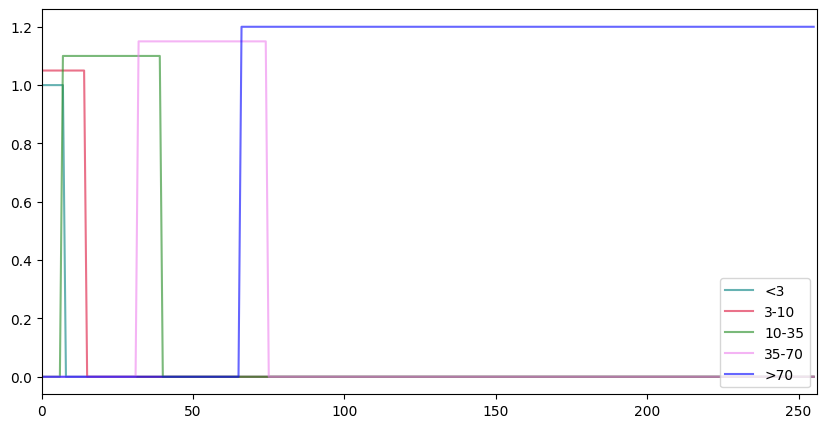

[[(0, 11)], [(0, 18)], [(5, 43)], [(30, 78)], [(64, 256)]]


In [7]:
supports = [filters.find_support(filt, EPSILON*1000, offset=i*0.05)[0] for i, filt in enumerate(windowed_sinc_filters)]
filters.plot_filters(names, supports, None, colours, plot_mask)

print([filters.find_support(filt, EPSILON*10, offset=i*0.05)[1] for i, filt in enumerate(windowed_sinc_filters)])

## Visibility histogram and close to ideal partitioning setup

create_named_configuration: MID
	(<Quantity 5109237.71471275 m>, <Quantity 2006795.66194638 m>, <Quantity -3239109.18380111 m>)
	GeodeticLocation(lon=<Longitude 21.443803 deg>, lat=<Latitude -30.712925 deg>, height=<Quantity 1053. m>)
create_configuration_from_file: 197 antennas/stations
create_visibility: created 8 times
create_visibility: 156024 rows, 0.009 GB


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


[0.502991221903377, 1.914596430511069, 6.149412056334144, 31.5583058112726, 232.94731557263663]


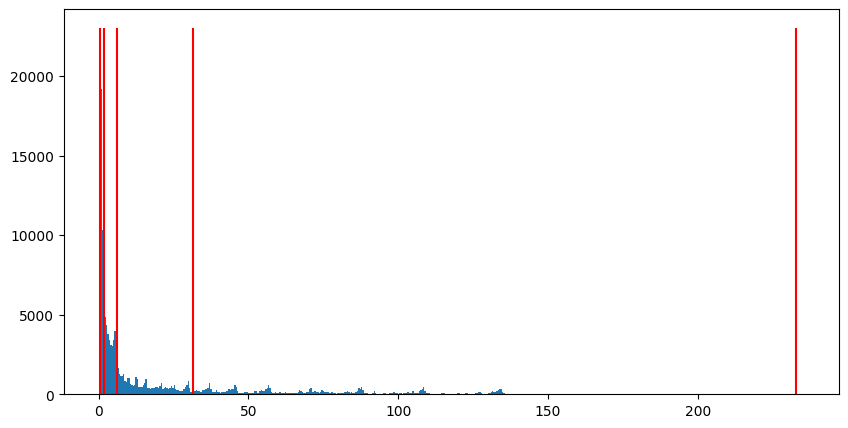

In [15]:
filters.generate_telescope_histogram(-35.0, "MID", 1e9, 500, 1, ha_interval = [-4, 4], \
                                     show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=0.0000008755170341876385,
                                     ignore_autocorrelation=True)